In [1]:
import pandas as pd
from localisation.localisation import Localisation
from general.helpers import Helper
from general.create_image import Animate
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# First get the Tracker list
archive_df = pd.read_csv("/Users/iain/Documents/projects/superapp_sprint/trackers/meituan_permissions.csv")
#archive_df.columns= ['sha','sha1','sha2','dexdate', 'apksize','package','?', 'virus','virusdate','!','market']
# Now to get the list of app and localisations
localised_df = pd.read_csv("/Users/iain/Documents/projects/superapp_sprint/localisation_meituan/ab_found-1.csv")
localised_df.columns = ['sha', 'local']

In [3]:
#merge the two together to enable sorting later. 
merged_df = pd.merge(archive_df, localised_df, on="sha")
merged_df

,Unnamed: 0,sha,permissions,features,package,version,major,minor,minor1,added,removed,same,local
0,3,02056CDE2FB55FD71EF19C5B6F647C6DF1F08C2EB7B5E5...,android.permission.READ_PHONE_STATE;android.p...,android.hardware.camera;android.hardware.came...,com.sankuai.meituan.meituanwaimaibusiness,6.34.0.63,6,34,0.6300,126,-14,0,com.huawei.hms
1,3,02056CDE2FB55FD71EF19C5B6F647C6DF1F08C2EB7B5E5...,android.permission.READ_PHONE_STATE;android.p...,android.hardware.camera;android.hardware.came...,com.sankuai.meituan.meituanwaimaibusiness,6.34.0.63,6,34,0.6300,126,-14,0,com.huawei.agconnect
2,3,02056CDE2FB55FD71EF19C5B6F647C6DF1F08C2EB7B5E5...,android.permission.READ_PHONE_STATE;android.p...,android.hardware.camera;android.hardware.came...,com.sankuai.meituan.meituanwaimaibusiness,6.34.0.63,6,34,0.6300,126,-14,0,com.huawei.updatesdk
3,7,0541F970E1D3D0056BD44EEAC99ADB45B23280C04D01FF...,com.sankuai.common.PERMISSION;android.permiss...,android.hardware.camera;android.hardware.came...,com.sankuai.meituan,11.11.403,11,11,403.0000,128,-9,0,com.huawei.hms
4,7,0541F970E1D3D0056BD44EEAC99ADB45B23280C04D01FF...,com.sankuai.common.PERMISSION;android.permiss...,android.hardware.camera;android.hardware.came...,com.sankuai.meituan,11.11.403,11,11,403.0000,128,-9,0,com.huawei.agconnect
...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,749,FF93D55E3A85664CA1B128758A67AD2B5E2922557B7B98...,android.permission.ACCESS_NETWORK_STATE;andro...,android.hardware.camera;android.hardware.came...,com.sankuai.meituan.dispatch.homebrew,8.4.0.1317,8,4,0.1317,43,-62,0,com.huawei.agconnect
823,749,FF93D55E3A85664CA1B128758A67AD2B5E2922557B7B98...,android.permission.ACCESS_NETWORK_STATE;andro...,android.hardware.camera;android.hardware.came...,com.sankuai.meituan.dispatch.homebrew,8.4.0.1317,8,4,0.1317,43,-62,0,com.huawei.updatesdk
824,750,FFC46539F355223D8CA5F7BC8988E8593FA16166DDD2BC...,com.sankuai.common.PERMISSION;android.permiss...,android.hardware.camera;android.hardware.came...,com.sankuai.meituan,12.1.204,12,1,204.0000,123,-43,0,com.huawei.hms
825,750,FFC46539F355223D8CA5F7BC8988E8593FA16166DDD2BC...,com.sankuai.common.PERMISSION;android.permiss...,android.hardware.camera;android.hardware.came...,com.sankuai.meituan,12.1.204,12,1,204.0000,123,-43,0,com.huawei.agconnect


In [4]:
majors = merged_df["major"].sort_values().unique()
ab_packages = merged_df["local"].sort_values().unique()
app_packages = merged_df["package"].sort_values().unique()
ab_packages

array([' com.huawei.agconnect', ' com.huawei.hms', ' com.huawei.hwid',
       ' com.huawei.updatesdk'], dtype=object)

In [5]:
for major in majors:
    tmp_df = merged_df[(merged_df["major"] == major) ]
    minors = tmp_df['minor'].unique()
    for minor in minors:
        g = nx.Graph()
        nodes = g.add_nodes_from(list(ab_packages) + list(app_packages))
        ver_df = tmp_df[tmp_df["minor"] == minor]
        g = nx.from_pandas_edgelist(ver_df,source="package", target="local")
        nx.draw(g, with_labels=True)
        plt.savefig("/Users/iain/Desktop/ab_networks/{}_{}_meituan.png".format(major, minor))
        plt.close()
        g.clear()

In [6]:
import os
from PIL import Image

In [7]:
images = os.listdir("/Users/iain/Desktop/ab_networks/")
image_strings = [str("/Users/iain/Desktop/ab_networks/" + p) for p in images if p.endswith('png')]
img = list(sorted(set(image_strings)))

image_data = [Image.open(p) for p in img]

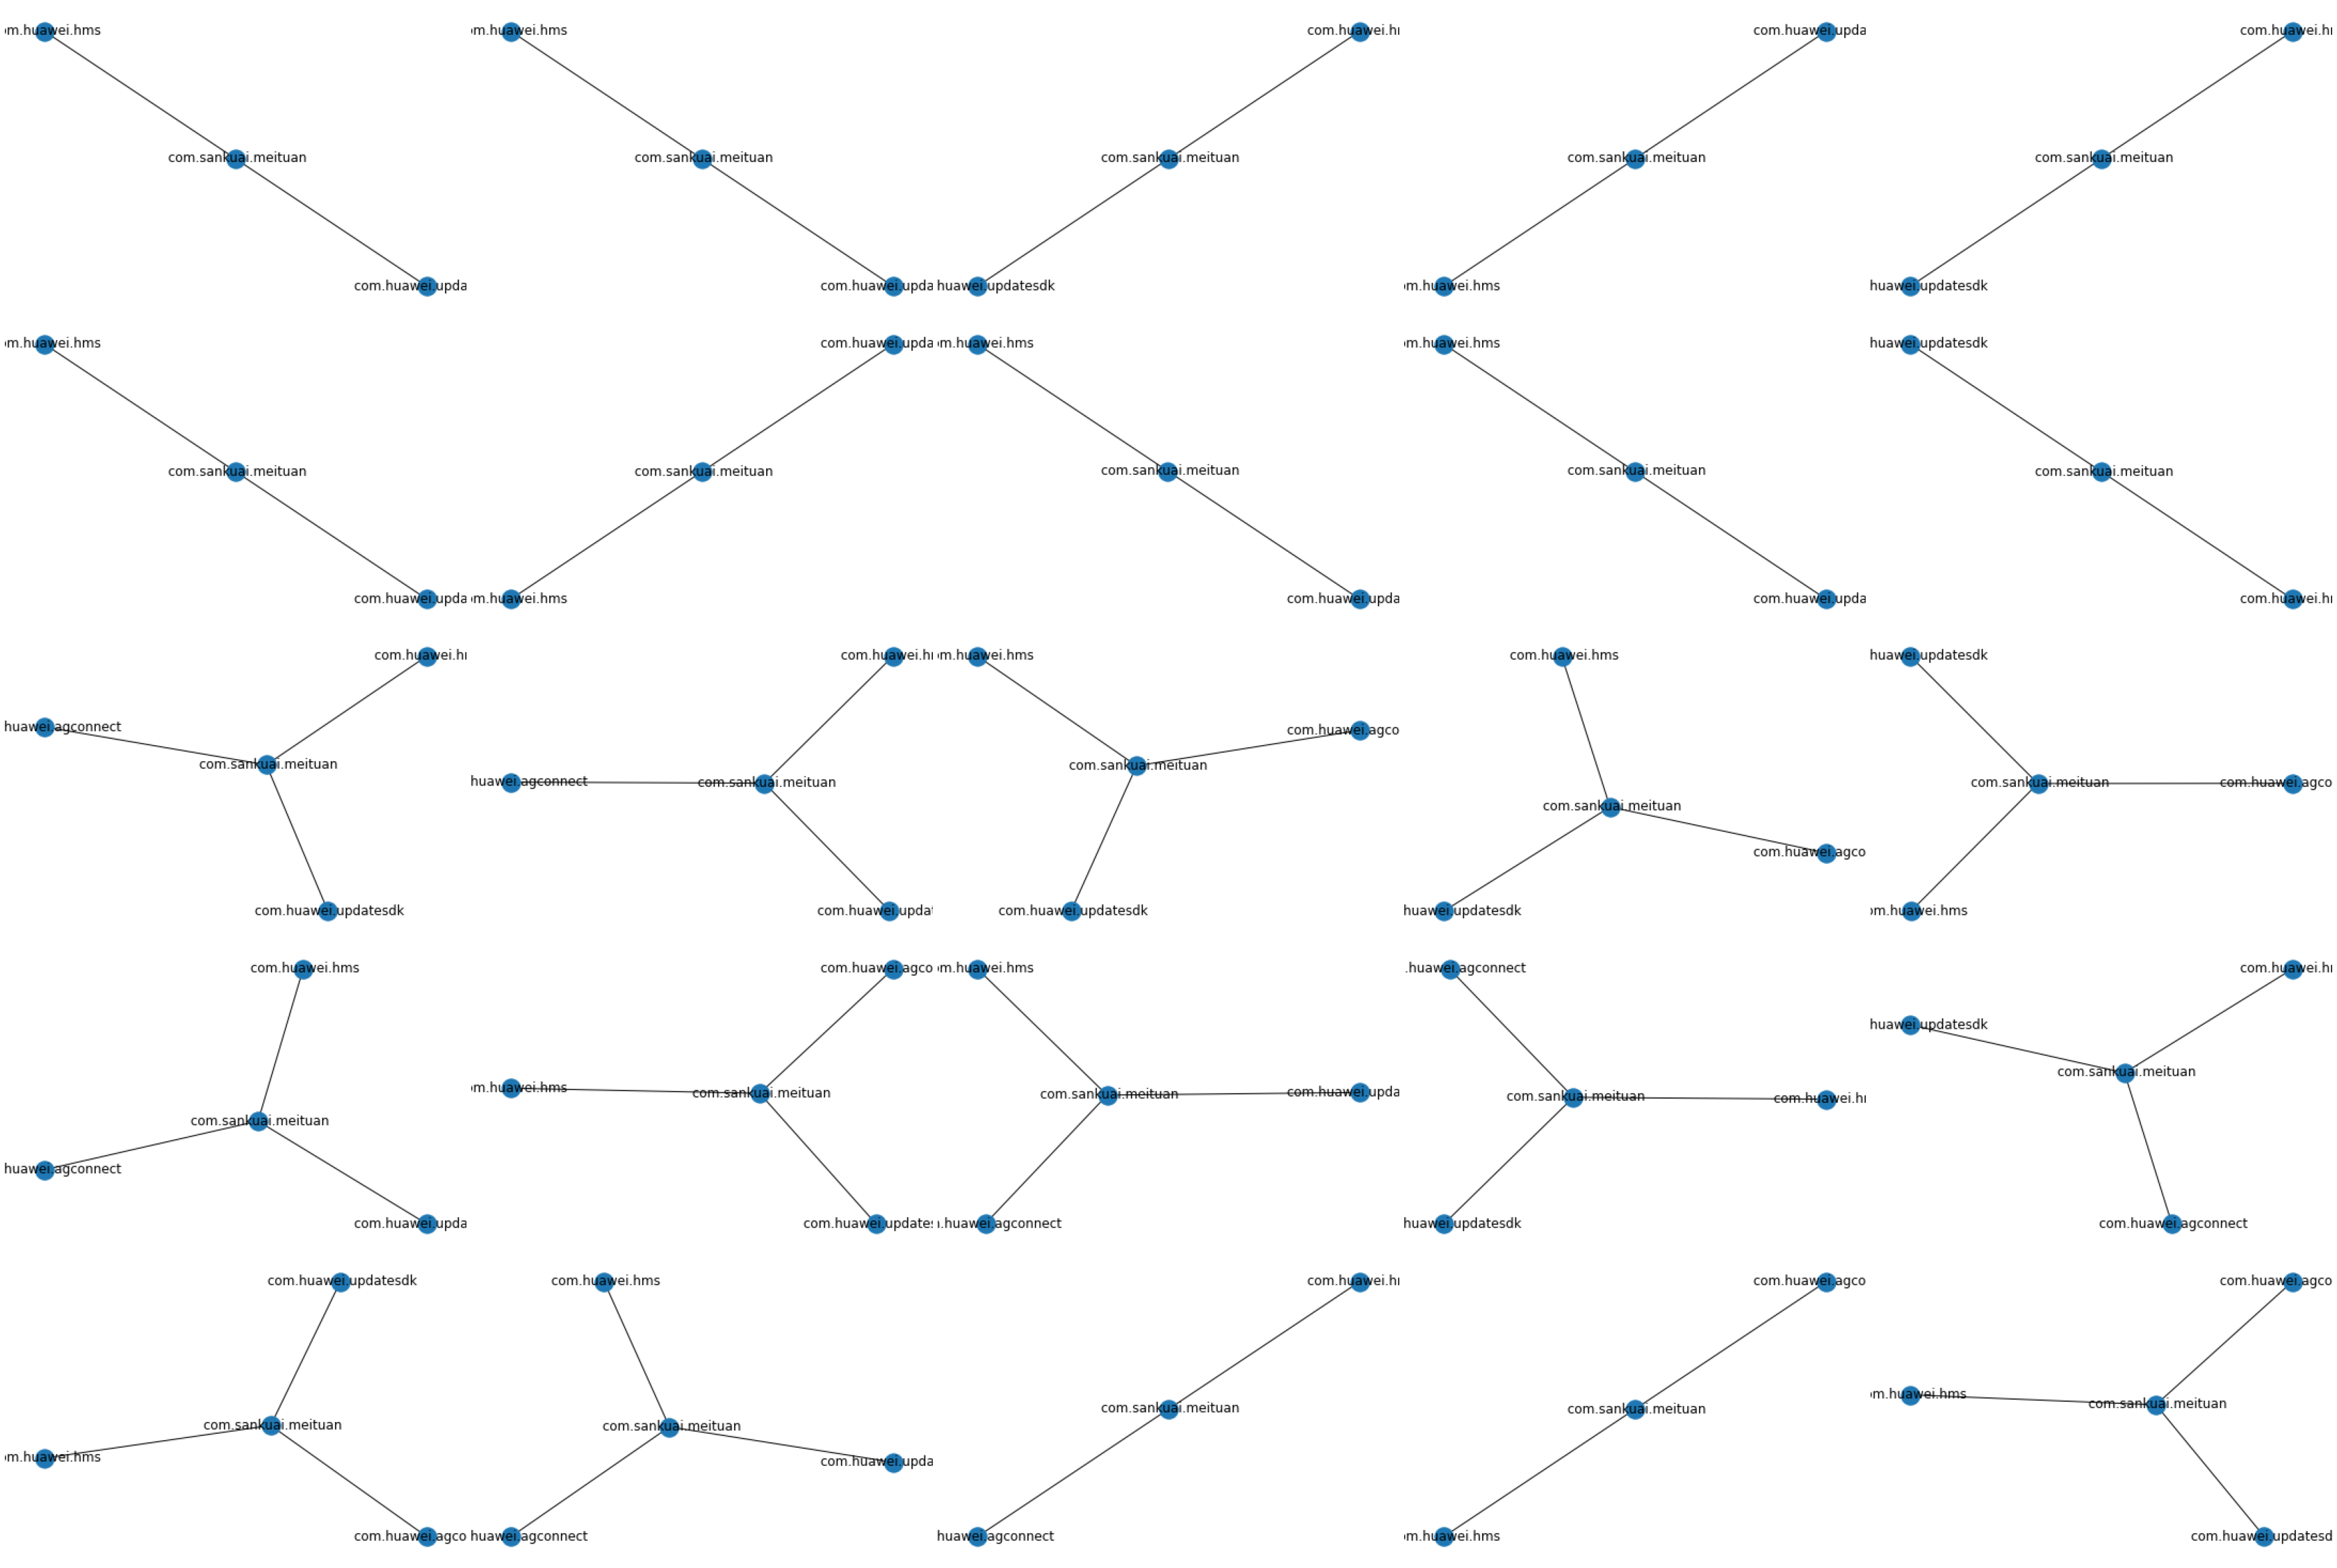

In [16]:
Animate().create_composite(image_data, "/Users/iain/Desktop/all_meitaun_ab_networks.png", nrow=20, ncol=7)

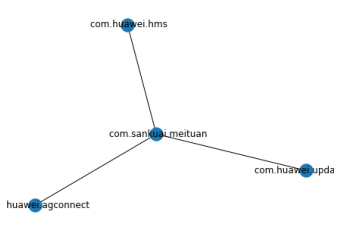

In [9]:
Animate().animate_images(image_strings, "/Users/iain/Desktop/animated_meituan_ab.mp4")